In [1]:
import os
os.chdir('/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/')

# general
import glob
import datetime as dt
from pathlib import Path


# data 
import xarray as xr 
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, LogLocator, NullFormatter, ScalarFormatter
import plotly.express as px 
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Configure Plotly for Jupyter notebooks
pio.renderers.default = "notebook"
# Alternative renderers you can try if "notebook" doesn't work:
# pio.renderers.default = "plotly_mimetype+notebook"
# pio.renderers.default = "jupyter_lab"

# helper tools
from metpy import calc, units
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from utils import helper_funcs

In [2]:
def get_file_destination(DATA_DIR, SRC, PRODUCT, WITH_MET, RAW_OR_NORMALIZED):
    if WITH_MET and RAW_OR_NORMALIZED == "raw":
        WITH_MET = "_with_raw_met"
    elif WITH_MET and RAW_OR_NORMALIZED == "normalized":
        WITH_MET = "_with_normalized_met"
    else:
        WITH_MET = ""

    if PRODUCT == "gridded":
        PRODUCT_NAME = "_gridded"
        FOLDER_NAME = "gridded_events"
    elif PRODUCT == "events":
        PRODUCT_NAME = ""
        FOLDER_NAME = "events"
    else:
        PRODUCT_NAME = ""
    if SRC in ['asfs', 'sos']:
        SITE = 'kettle_ponds'
    elif SRC in ['bb', 'sail']:
        SITE = 'gothic'
    else:
        SITE = input("Enter site name (gothic or kettle_ponds): ")
    return DATA_DIR / SITE / f"{FOLDER_NAME}{WITH_MET}" / f"{SITE}{PRODUCT_NAME}_precipitation_event_comparisons_{SRC}{WITH_MET}.nc"

# Gothic

# Event Total Plots

In [25]:
DATA_DIR = '/storage/dlhogan/precipitation-rodeo/data/for_analysis'
# Define your root and sites
DATA_DIR = Path(DATA_DIR)
STORAGE_DIR = '/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/events'
SRC = "sail" # one of [bb, sail, asfs, sos, '']
PRODUCT = "events" # or events
WITH_MET = True  # or True
RAW_OR_NORMALIZED = "raw"  # or raw
file_dest = get_file_destination(DATA_DIR, SRC, PRODUCT, WITH_MET, RAW_OR_NORMALIZED)
print(f"Loading data from: {file_dest}")

ds = xr.open_dataset(file_dest).sel(event_id=slice(1, 10))
PRODUCT = "gridded"
gridded_ds = xr.open_dataset(get_file_destination(DATA_DIR, SRC, PRODUCT, WITH_MET, RAW_OR_NORMALIZED)).sel(event_id=slice(1, 10))

Loading data from: /storage/dlhogan/precipitation-rodeo/data/for_analysis/gothic/events_with_raw_met/gothic_precipitation_event_comparisons_sail_with_raw_met.nc


In [26]:
instrument_plot_dict = helper_funcs.INSTRUMENT_PLOT_DICT

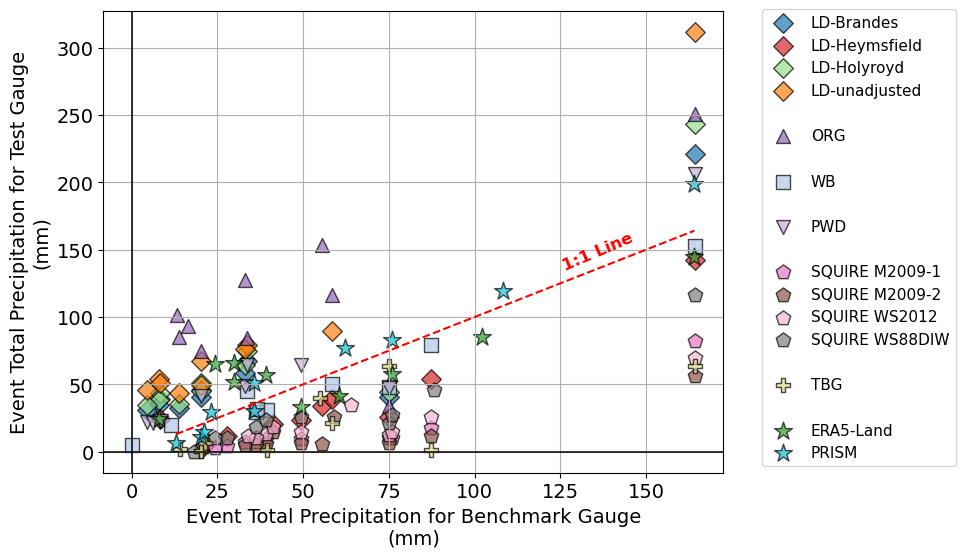

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))

for test_instrument in ds['test_instrument'].values:
    if test_instrument == 'billy_barr_precip':
        continue
    sub_ds = ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['others_total'].dropna('event_id')

    # scatter plot with regression line
    
    ax.scatter(benchmark, test_precip, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)
    # blank spots for legend
    if test_instrument in ['sail_ld_unadjusted', 'sail_org', 'sail_pluvio', 'sail_squire_ws88diw',  'sail_pwd', 'sail_tbg']:
        ax.scatter([], [], label=' ',
               color='white',
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=100)
for test_instrument in ['era5_land_tp', 'prism_ppt']:
    sub_ds = gridded_ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['others_total'].dropna('event_id')

    # scatter plot with regression line
    
    ax.scatter(benchmark, test_precip, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)

ax.plot([benchmark.min(), benchmark.max()], [benchmark.min(), benchmark.max()], 'r--',)
# label the 1-1 line with text
ax.text(125, 135, rotation=23, s='1:1 Line', color='red', fontsize=12, weight='bold')
ax.axhline(0, color='black', linewidth=1.1)
ax.axvline(0, color='black', linewidth=1.1)
ax.set_xlabel('Event Total Precipitation for Benchmark Gauge\n(mm)', fontsize=14)
ax.set_ylabel('Event Total Precipitation for Test Gauge\n(mm)', fontsize=14)
# ax.set_title('Event Total Precipitation Comparison', fontsize=16)

# set tick label size
# use fixed locator to avoid matplotlib warning
ax.xaxis.set_major_locator(FixedLocator(ax.get_xticks()))
ax.yaxis.set_major_locator(FixedLocator(ax.get_yticks()))
ax.set_xticklabels(ax.get_xticks().astype(int), fontsize=14)
ax.set_yticklabels(ax.get_yticks().astype(int), fontsize=14)
ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1.02), loc='upper left',  title_fontsize='13', fontsize='11')
fig.savefig('/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/for_manuscript/gt_event_total_precipitations.png', bbox_inches='tight', dpi=600)

# Event absolute difference comparison

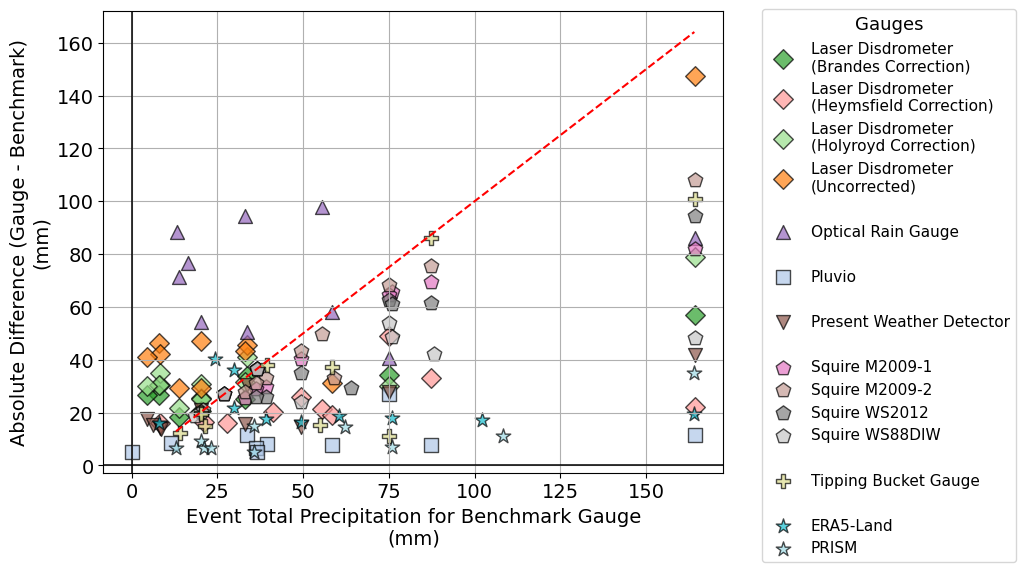

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for test_instrument in ds['test_instrument'].values:
    if test_instrument == 'billy_barr_precip':
        continue
    sub_ds = ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['abs_diff'].dropna('event_id')

    # scatter plot with regression line
    
    ax.scatter(benchmark, test_precip, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)
    # blank spots for legend
    if test_instrument in ['sail_ld_unadjusted', 'sail_org', 'sail_pluvio', 'sail_squire_ws88diw',  'sail_pwd', 'sail_tbg']:
        ax.scatter([], [], label=' ',
               color='white',
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=100)
for test_instrument in ['era5_land_tp', 'prism_ppt']:
    sub_ds = gridded_ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['abs_diff'].dropna('event_id')

    # scatter plot with regression line
    
    ax.scatter(benchmark, test_precip, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)

ax.plot([benchmark.min(), benchmark.max()], [benchmark.min(), benchmark.max()], 'r--',)
ax.axhline(0, color='black', linewidth=1.1)
ax.axvline(0, color='black', linewidth=1.1)
ax.set_xlabel('Event Total Precipitation for Benchmark Gauge\n(mm)', fontsize=14)
ax.set_ylabel('Absolute Difference (Gauge - Benchmark)\n(mm)', fontsize=14)
# ax.set_title('Event Total Precipitation Comparison', fontsize=16)

# set tick label size
# use fixed locator to avoid matplotlib warning
ax.xaxis.set_major_locator(FixedLocator(ax.get_xticks()))
ax.yaxis.set_major_locator(FixedLocator(ax.get_yticks()))
ax.set_xticklabels(ax.get_xticks().astype(int), fontsize=14)
ax.set_yticklabels(ax.get_yticks().astype(int), fontsize=14)
ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1.02), loc='upper left',  title_fontsize='13', fontsize='11')


# Event Difference Comparison

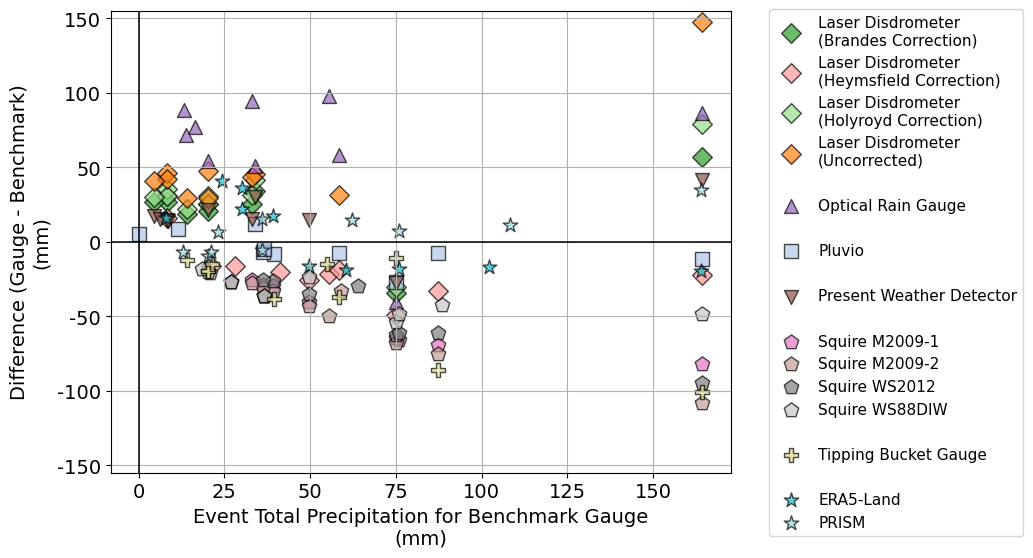

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for test_instrument in ds['test_instrument'].values:
    if test_instrument == 'billy_barr_precip':
        continue
    sub_ds = ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['diff'].dropna('event_id')

    # scatter plot with regression line
    
    ax.scatter(benchmark, test_precip, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)
    # blank spots for legend
    if test_instrument in ['sail_ld_unadjusted', 'sail_org', 'sail_pluvio', 'sail_squire_ws88diw',  'sail_pwd', 'sail_tbg']:
        ax.scatter([], [], label=' ',
               color='white',
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=100)
for test_instrument in ['era5_land_tp', 'prism_ppt']:
    sub_ds = gridded_ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['diff'].dropna('event_id')

    # scatter plot with regression line
    
    ax.scatter(benchmark, test_precip, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)
ax.set_ylim(-155,155)

# ax.plot([benchmark.min(), benchmark.max()], [benchmark.min(), benchmark.max()], 'r--',)
ax.axhline(0, color='black', linewidth=1.1)
ax.axvline(0, color='black', linewidth=1.1)
ax.set_xlabel('Event Total Precipitation for Benchmark Gauge\n(mm)', fontsize=14)
ax.set_ylabel('Difference (Gauge - Benchmark)\n(mm)', fontsize=14)
# ax.set_title('Event Total Precipitation Comparison', fontsize=16)

# set tick label size
# use fixed locator to avoid matplotlib warning
ax.xaxis.set_major_locator(FixedLocator(ax.get_xticks()))
ax.yaxis.set_major_locator(FixedLocator(ax.get_yticks()))
ax.set_xticklabels(ax.get_xticks().astype(int), fontsize=14)
ax.set_yticklabels(ax.get_yticks().astype(int), fontsize=14)
ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1.02), loc='upper left',  title_fontsize='13', fontsize='11')


# Event Normalized Difference 

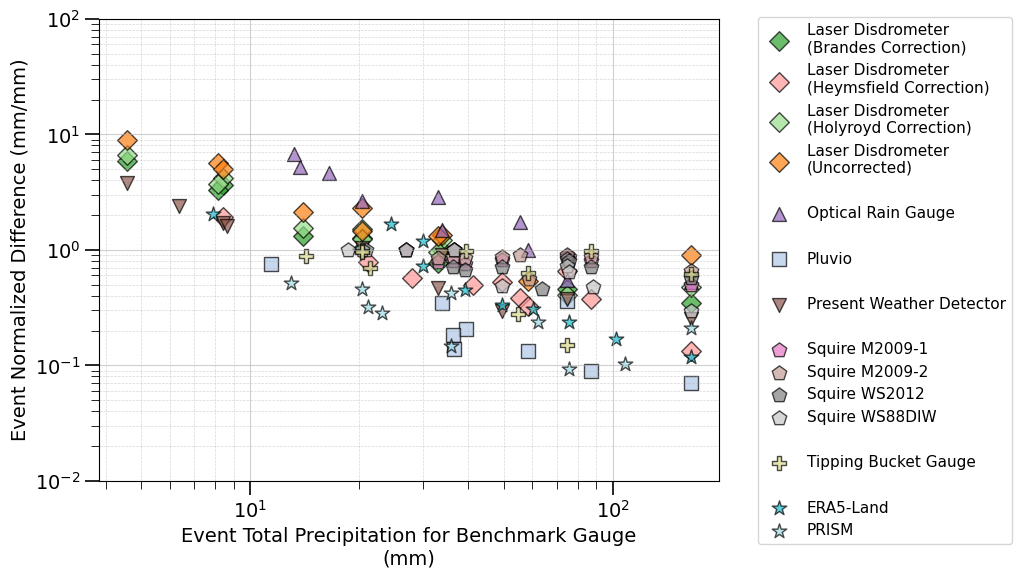

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for test_instrument in ds['test_instrument'].values:
    if test_instrument == 'billy_barr_precip':
        continue
    sub_ds = ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    # drop 0 values
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['abs_diff'].dropna('event_id')

    normalized = test_precip / benchmark
    # make sure value is finite
    normalized = normalized.where(np.isfinite(normalized), drop=True)
    normalized_index = normalized['event_id'].values
    # scatter plot with regression line

    ax.scatter(benchmark.sel(event_id=normalized_index), normalized, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)
    # blank spots for legend
    if test_instrument in ['sail_ld_unadjusted', 'sail_org', 'sail_pluvio', 'sail_squire_ws88diw',  'sail_pwd', 'sail_tbg']:
        ax.scatter([], [], label=' ',
               color='white',
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=100)
for test_instrument in ['era5_land_tp', 'prism_ppt']:
    sub_ds = gridded_ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['abs_diff'].dropna('event_id')

    normalized = test_precip / benchmark

    # scatter plot with regression line

    ax.scatter(benchmark, normalized, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)

ax.set_xlabel('Event Total Precipitation for Benchmark Gauge\n(mm)', fontsize=14)
ax.set_ylabel('Event Normalized Difference (mm/mm)', fontsize=14)

ax.set_xscale('log')
ax.set_yscale('log')

# Major ticks at decades, minor ticks at subdivisions
ax.yaxis.set_major_locator(LogLocator(base=10.0))       # decades
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs='auto', numticks=11))  # subdivisions

# Formatters: show nice major tick labels, hide minor labels
# ax.yaxis.set_major_formatter(ScalarFormatter())   # shows 1, 10, 100 etc instead of 1e0, 1e1
ax.yaxis.set_minor_formatter(NullFormatter())

# Make tick fonts readable (no manual casting to int)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.tick_params(axis='both', which='minor', length=6)   # minor tick length
ax.tick_params(axis='both', which='major', length=10, width=1.2)

# Optional: show grid lines for both major and minor
ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_ylim(0.01, 100)

ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1.02), loc='upper left',  title_fontsize='13', fontsize='11')


# Kettle ponds

In [19]:
DATA_DIR = '/storage/dlhogan/precipitation-rodeo/data/for_analysis'
# Define your root and sites
DATA_DIR = Path(DATA_DIR)
STORAGE_DIR = '/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/events'
SRC = "asfs" # one of [bb, sail, asfs, sos, '']
PRODUCT = "events" # or events
WITH_MET = True  # or True
RAW_OR_NORMALIZED = "raw"  # or raw
file_dest = get_file_destination(DATA_DIR, SRC, PRODUCT, WITH_MET, RAW_OR_NORMALIZED)
print(f"Loading data from: {file_dest}")

ds = xr.open_dataset(file_dest).sel(event_id=slice(1, 10))
PRODUCT = "gridded"
gridded_ds = xr.open_dataset(get_file_destination(DATA_DIR, SRC, PRODUCT, WITH_MET, RAW_OR_NORMALIZED)).sel(event_id=slice(1, 10))

Loading data from: /storage/dlhogan/precipitation-rodeo/data/for_analysis/kettle_ponds/events_with_raw_met/kettle_ponds_precipitation_event_comparisons_asfs_with_raw_met.nc


# Event Total Plots

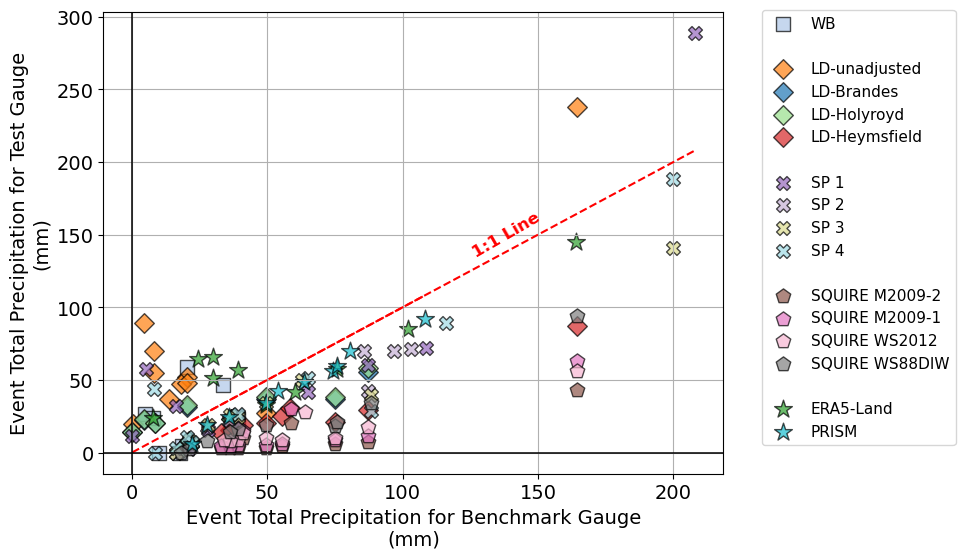

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot([ds.sel(benchmark='billy_barr_precip', test_instrument='sos_SWE_p1')['benchmark_total'].min(), 
         ds.sel(benchmark='billy_barr_precip', test_instrument='sos_SWE_p1')['benchmark_total'].max()], 
         [ds.sel(benchmark='billy_barr_precip', test_instrument='sos_SWE_p1')['benchmark_total'].min(), 
          ds.sel(benchmark='billy_barr_precip', test_instrument='sos_SWE_p1')['benchmark_total'].max()], 'r--',)
for test_instrument in list(instrument_plot_dict.keys()):
    if test_instrument not in ds.test_instrument.values:
        continue
    if test_instrument == 'billy_barr_precip':
        continue
    sub_ds = ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['others_total'].dropna('event_id')

    # scatter plot with regression line
    
    ax.scatter(benchmark, test_precip, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)
    # blank spots for legend
    if test_instrument in ['sail_ld_unadjusted', 'sail_org', 'sail_pluvio', 'sail_squire_ws88diw',  'sail_pwd', 'sail_tbg', 'sos_SWE_p4', 'splash_ld_heymsfield', 'splash_pluvio']:
        ax.scatter([], [], label=' ',
               color='white',
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=100)
for test_instrument in ['era5_land_tp', 'prism_ppt']:
    sub_ds = gridded_ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['others_total'].dropna('event_id')

    # scatter plot with regression line
    
    ax.scatter(benchmark, test_precip, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)

ax.plot([benchmark.min(), benchmark.max()], [benchmark.min(), benchmark.max()], 'r--',)
# label the 1-1 line with text
ax.text(125, 135, rotation=30, s='1:1 Line', color='red', fontsize=12, weight='bold')
ax.axhline(0, color='black', linewidth=1.1)
ax.axvline(0, color='black', linewidth=1.1)
ax.set_xlabel('Event Total Precipitation for Benchmark Gauge\n(mm)', fontsize=14)
ax.set_ylabel('Event Total Precipitation for Test Gauge\n(mm)', fontsize=14)
# ax.set_title('Event Total Precipitation Comparison', fontsize=16)

# set tick label size
# use fixed locator to avoid matplotlib warning
ax.xaxis.set_major_locator(FixedLocator(ax.get_xticks()))
ax.yaxis.set_major_locator(FixedLocator(ax.get_yticks()))
ax.set_xticklabels(ax.get_xticks().astype(int), fontsize=14)
ax.set_yticklabels(ax.get_yticks().astype(int), fontsize=14)
ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1.02), loc='upper left',  title_fontsize='13', fontsize='11')
fig.savefig('/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/for_manuscript/kp_event_total_precipitations.png', bbox_inches='tight', dpi=600)

# Event absolute difference comparison

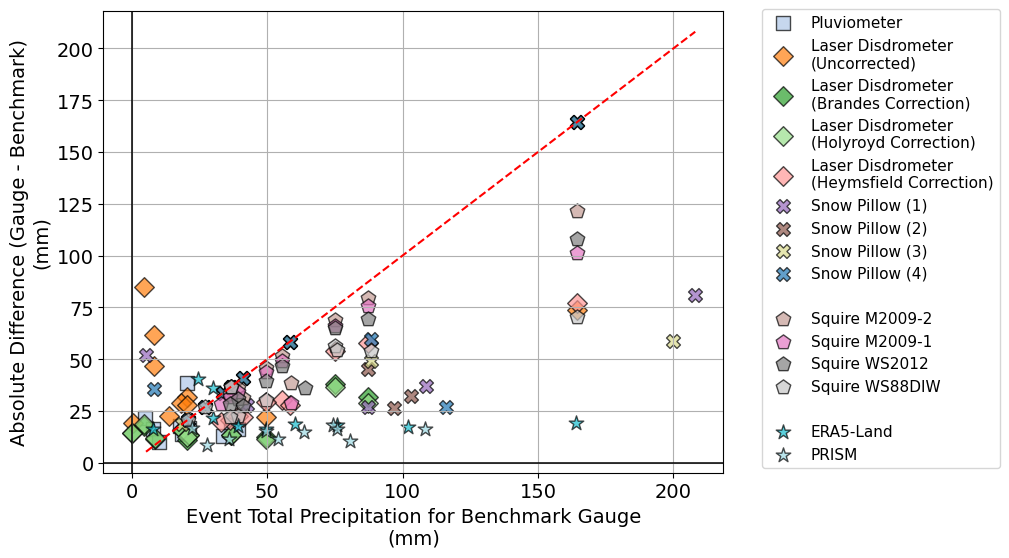

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot([ds.sel(benchmark='billy_barr_precip', test_instrument='sos_SWE_p1')['benchmark_total'].min(), 
         ds.sel(benchmark='billy_barr_precip', test_instrument='sos_SWE_p1')['benchmark_total'].max()], 
         [ds.sel(benchmark='billy_barr_precip', test_instrument='sos_SWE_p1')['benchmark_total'].min(), 
          ds.sel(benchmark='billy_barr_precip', test_instrument='sos_SWE_p1')['benchmark_total'].max()], 'r--',)

for test_instrument in list(instrument_plot_dict.keys()):
    if test_instrument not in ds.test_instrument.values:
        continue
    if test_instrument == 'billy_barr_precip':
        continue
    sub_ds = ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['abs_diff'].dropna('event_id')

    # scatter plot with regression line
    
    ax.scatter(benchmark, test_precip, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)
    # blank spots for legend
    if test_instrument in ['sail_ld_unadjusted', 'sail_org', 'sail_pluvio', 'sail_squire_ws88diw',  'sail_pwd', 'sail_tbg', 'sos_SWE_p4', 'sail_ld_heymsfield']:
        ax.scatter([], [], label=' ',
               color='white',
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=100)
for test_instrument in ['era5_land_tp', 'prism_ppt']:
    sub_ds = gridded_ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['abs_diff'].dropna('event_id')

    # scatter plot with regression line
    
    ax.scatter(benchmark, test_precip, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)

ax.axhline(0, color='black', linewidth=1.1)
ax.axvline(0, color='black', linewidth=1.1)
ax.set_xlabel('Event Total Precipitation for Benchmark Gauge\n(mm)', fontsize=14)
ax.set_ylabel('Absolute Difference (Gauge - Benchmark)\n(mm)', fontsize=14)
# ax.set_title('Event Total Precipitation Comparison', fontsize=16)

# set tick label size
# use fixed locator to avoid matplotlib warning
ax.xaxis.set_major_locator(FixedLocator(ax.get_xticks()))
ax.yaxis.set_major_locator(FixedLocator(ax.get_yticks()))
ax.set_xticklabels(ax.get_xticks().astype(int), fontsize=14)
ax.set_yticklabels(ax.get_yticks().astype(int), fontsize=14)
ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1.02), loc='upper left',  title_fontsize='13', fontsize='11')


# Event Difference Comparison

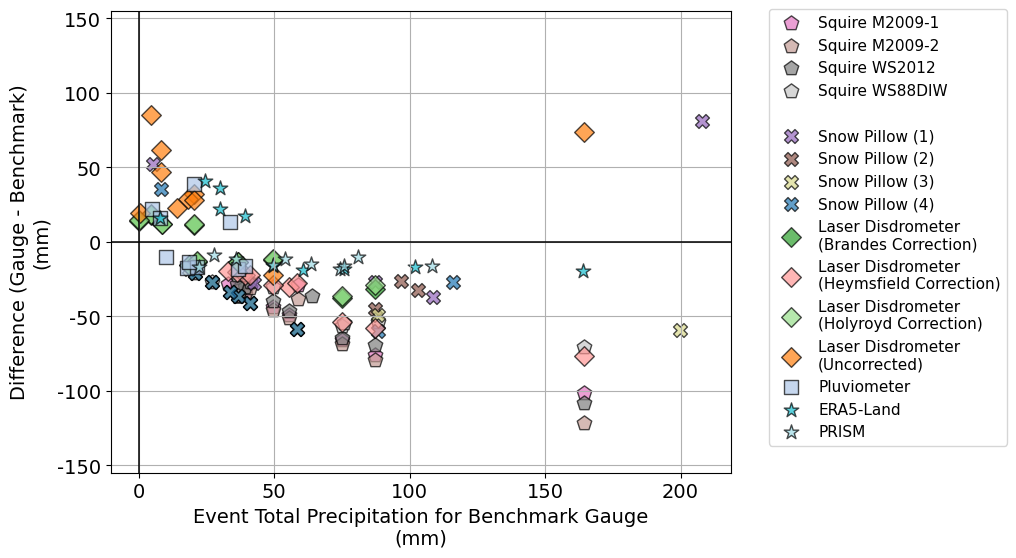

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for test_instrument in ds['test_instrument'].values:
    if test_instrument == 'billy_barr_precip':
        continue
    sub_ds = ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['diff'].dropna('event_id')

    # scatter plot with regression line
    
    ax.scatter(benchmark, test_precip, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)
    # blank spots for legend
    if test_instrument in ['sail_ld_unadjusted', 'sail_org', 'sail_pluvio', 'sail_squire_ws88diw',  'sail_pwd', 'sail_tbg']:
        ax.scatter([], [], label=' ',
               color='white',
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=100)
for test_instrument in ['era5_land_tp', 'prism_ppt']:
    sub_ds = gridded_ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['diff'].dropna('event_id')

    # scatter plot with regression line
    
    ax.scatter(benchmark, test_precip, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)
ax.set_ylim(-155,155)

# ax.plot([benchmark.min(), benchmark.max()], [benchmark.min(), benchmark.max()], 'r--',)
ax.axhline(0, color='black', linewidth=1.1)
ax.axvline(0, color='black', linewidth=1.1)
ax.set_xlabel('Event Total Precipitation for Benchmark Gauge\n(mm)', fontsize=14)
ax.set_ylabel('Difference (Gauge - Benchmark)\n(mm)', fontsize=14)
# ax.set_title('Event Total Precipitation Comparison', fontsize=16)

# set tick label size
# use fixed locator to avoid matplotlib warning
ax.xaxis.set_major_locator(FixedLocator(ax.get_xticks()))
ax.yaxis.set_major_locator(FixedLocator(ax.get_yticks()))
ax.set_xticklabels(ax.get_xticks().astype(int), fontsize=14)
ax.set_yticklabels(ax.get_yticks().astype(int), fontsize=14)
ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1.02), loc='upper left',  title_fontsize='13', fontsize='11')


# Event Normalized Difference 

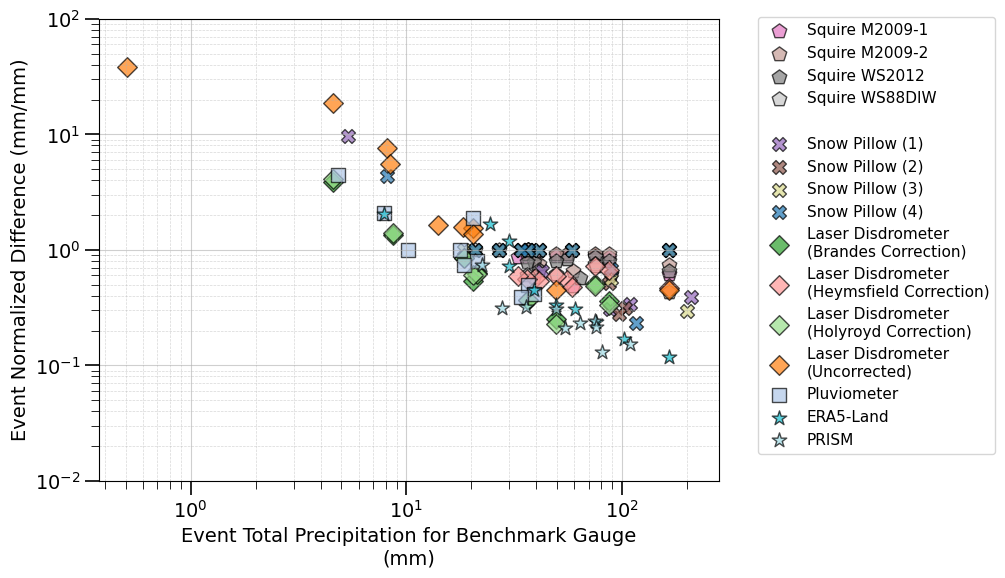

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for test_instrument in ds['test_instrument'].values:
    if test_instrument == 'billy_barr_precip':
        continue
    sub_ds = ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    # drop 0 values
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['abs_diff'].dropna('event_id')

    normalized = test_precip / benchmark
    # make sure value is finite
    normalized = normalized.where(np.isfinite(normalized), drop=True)
    normalized_index = normalized['event_id'].values
    # scatter plot with regression line

    ax.scatter(benchmark.sel(event_id=normalized_index), normalized, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)
    # blank spots for legend
    if test_instrument in ['sail_ld_unadjusted', 'sail_org', 'sail_pluvio', 'sail_squire_ws88diw',  'sail_pwd', 'sail_tbg']:
        ax.scatter([], [], label=' ',
               color='white',
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=100)
for test_instrument in ['era5_land_tp', 'prism_ppt']:
    sub_ds = gridded_ds.sel(benchmark='billy_barr_precip', test_instrument=test_instrument) 
    benchmark = sub_ds['benchmark_total'].dropna('event_id')
    test_precip = sub_ds['abs_diff'].dropna('event_id')

    normalized = test_precip / benchmark

    # scatter plot with regression line

    ax.scatter(benchmark, normalized, alpha=0.7, label=instrument_plot_dict[test_instrument]['name'],
               color=instrument_plot_dict[test_instrument]['color'],
               marker=instrument_plot_dict[test_instrument]['marker'],
               s=instrument_plot_dict[test_instrument]['size'],
               ec='black',)

ax.set_xlabel('Event Total Precipitation for Benchmark Gauge\n(mm)', fontsize=14)
ax.set_ylabel('Event Normalized Difference (mm/mm)', fontsize=14)

ax.set_xscale('log')
ax.set_yscale('log')

# Major ticks at decades, minor ticks at subdivisions
ax.yaxis.set_major_locator(LogLocator(base=10.0))       # decades
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs='auto', numticks=11))  # subdivisions

# Formatters: show nice major tick labels, hide minor labels
# ax.yaxis.set_major_formatter(ScalarFormatter())   # shows 1, 10, 100 etc instead of 1e0, 1e1
ax.yaxis.set_minor_formatter(NullFormatter())

# Make tick fonts readable (no manual casting to int)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.tick_params(axis='both', which='minor', length=6)   # minor tick length
ax.tick_params(axis='both', which='major', length=10, width=1.2)

# Optional: show grid lines for both major and minor
ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_ylim(0.01, 100)

ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1.02), loc='upper left',  title_fontsize='13', fontsize='11')


# Event size rank correlation
To do: just add all sites and color the two differently

In [51]:
vars_to_remove =["billy_barr_precip", "sail_pwd_rain", "sail_squire_rain", "sail_tbg_corr", "rain_rate_A"]
rank_correlations = {}
for instrument in ds.test_instrument.values:
    if instrument in vars_to_remove:
        continue
    sub_df = ds.sel(benchmark='billy_barr_precip', test_instrument=instrument, event_id=slice(1,50))[['benchmark_total','abs_diff']].to_dataframe()
    sub_df = sub_df.reset_index()
    sub_df = sub_df.sort_values('benchmark_total', ascending=False)
    sub_df = sub_df.reset_index(drop=True)
    sub_df.index.name = 'event_ppt_rank'
    sub_df = sub_df.reset_index()
    sub_df['event_ppt_rank'] = sub_df['event_ppt_rank'] + 1  # make rank start at 1
    sub_df = sub_df.dropna()
    corr, p_value = stats.spearmanr(sub_df['event_ppt_rank'], sub_df['event_id'])
    rank_correlations[instrument] = (corr, p_value)

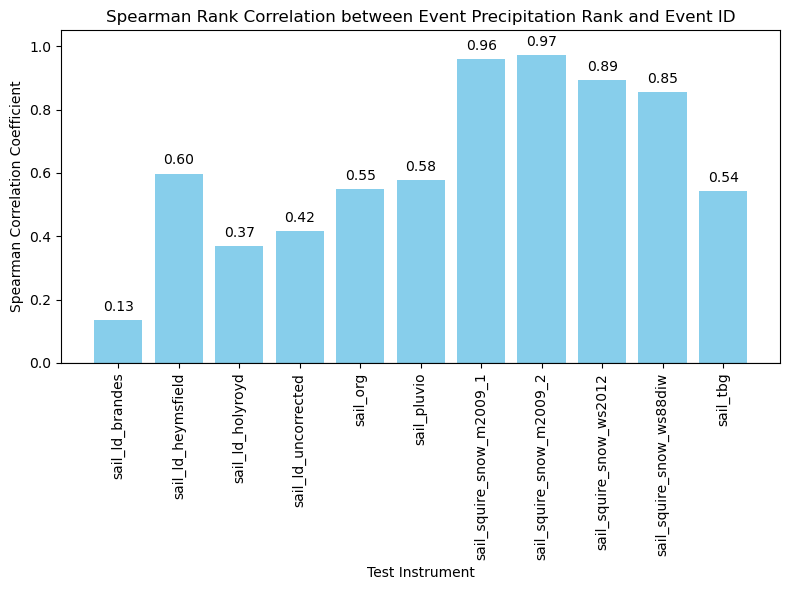

In [52]:
# build a dataframe from the results
rank_corr_df = pd.DataFrame.from_dict(rank_correlations, orient='index', columns=['spearman_correlation', 'p_value'])

plt.figure(figsize=(8,6))
bars = plt.bar(rank_corr_df.index, rank_corr_df['spearman_correlation'], color='skyblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Spearman Rank Correlation between Event Precipitation Rank and Event ID')
plt.xlabel('Test Instrument')
plt.ylabel('Spearman Correlation Coefficient')
plt.ylim(0, 1.05)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Normalized Event size rank correlation
To do: just add all sites and color the two differently

In [87]:
# lets compare the ranks of the normalized bias to the event ids
rank_correlations = {}
for instrument in ds.test_instrument.values:
    if instrument in vars_to_remove:
        continue
    sub_df = ds.sel(benchmark='billy_barr_precip', test_instrument=instrument)[['benchmark_total','abs_diff']].to_dataframe()
    sub_df = sub_df.reset_index()
    sub_df = sub_df.sort_values('benchmark_total', ascending=False)
    sub_df = sub_df.reset_index(drop=True)
    sub_df.index.name = 'event_ppt_rank'
    sub_df = sub_df.reset_index()
    sub_df['event_ppt_rank'] = sub_df['event_ppt_rank'] + 1  # make rank start at 1
    sub_df = sub_df.dropna()
    normalized_bias = sub_df['abs_diff'] / sub_df['benchmark_total']
    min_event_size = 2.5 # in mm
    normalized_bias = normalized_bias.where(sub_df['benchmark_total'] >= min_event_size, 0)
    normalized_bias = normalized_bias.where(np.isfinite(normalized_bias), 10)
    normalized_bias = normalized_bias.sort_values(ascending=False)
    # drop values where normalized_bias is 0
    normalized_bias = normalized_bias[normalized_bias > 0]
    corr, p_value = stats.spearmanr(normalized_bias.index, sub_df.loc[normalized_bias.index]['event_id'])
    rank_correlations[instrument] = (corr, p_value)
rank_corr_df = pd.DataFrame.from_dict(rank_correlations, orient='index', columns=['spearman_correlation', 'p_value'])

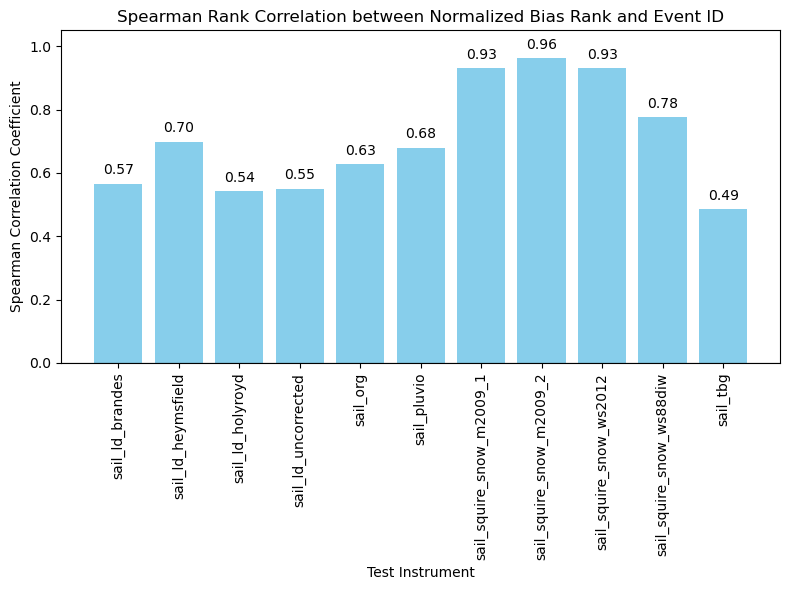

In [88]:
rank_corr_df = pd.DataFrame.from_dict(rank_correlations, orient='index', columns=['spearman_correlation', 'p_value'])
plt.figure(figsize=(8,6))
bars = plt.bar(rank_corr_df.index, rank_corr_df['spearman_correlation'], color='skyblue')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Spearman Rank Correlation between Normalized Bias Rank and Event ID')
plt.xlabel('Test Instrument')
plt.ylabel('Spearman Correlation Coefficient')
plt.ylim(0, 1.05)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()